In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv("../data/stud.csv")

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
data.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
for col in data.columns:
    print(f"In column '{col}' exist {data[col].nunique()} values: {data[col].unique()}")

In column 'gender' exist 2 values: ['female' 'male']
In column 'race_ethnicity' exist 5 values: ['group B' 'group C' 'group A' 'group D' 'group E']
In column 'parental_level_of_education' exist 6 values: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
In column 'lunch' exist 2 values: ['standard' 'free/reduced']
In column 'test_preparation_course' exist 2 values: ['none' 'completed']
In column 'math_score' exist 81 values: [ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]
In column 'reading_score' exist 72 values: [ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17 

In [8]:
numerical_cols = [col for col in data.columns if data[col].dtype != 'O']
categorical_cols = [col for col in data.columns if data[col].dtype == 'O']
print(numerical_cols)
print(categorical_cols)

['math_score', 'reading_score', 'writing_score']
['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [9]:
data["average"] = (data["math_score"] + data["reading_score"] + data["writing_score"]) / 3

In [10]:
reading_full = data[data['reading_score'] == 100]['average'].count()  # show only stats by scores, not averages
writing_full = data[data['writing_score'] == 100]['average'].count()
math_full = data[data['math_score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [11]:
reading_full = data[data['reading_score'] == 100]['average'].mean() # show averages
writing_full = data[data['writing_score'] == 100]['average'].mean()
math_full = data[data['math_score'] == 100]['average'].mean()

print(f'Mean average score of students with full marks in Maths: {math_full}')
print(f'Mean average score of students with full marks in Writing: {writing_full}')
print(f'Mean average score of students with full marks in Reading: {reading_full}')

Mean average score of students with full marks in Maths: 98.0952380952381
Mean average score of students with full marks in Writing: 97.73809523809521
Mean average score of students with full marks in Reading: 97.74509803921568


In [12]:
reading_less_20 = data[data['reading_score'] <= 20]['average'].count()
writing_less_20 = data[data['writing_score'] <= 20]['average'].count()
math_less_20 = data[data['math_score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


In [13]:
reading_less_20 = data[data['reading_score'] <= 20]['average'].mean()
writing_less_20 = data[data['writing_score'] <= 20]['average'].mean()
math_less_20 = data[data['math_score'] <= 20]['average'].mean()

print(f'Mean average score of students with less than 20 marks in Maths: {math_less_20}')
print(f'Mean average score of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Mean average score of students with less than 20 marks in Reading: {reading_less_20}')

Mean average score of students with less than 20 marks in Maths: 20.75
Mean average score of students with less than 20 marks in Writing: 18.444444444444443
Mean average score of students with less than 20 marks in Reading: 9.0


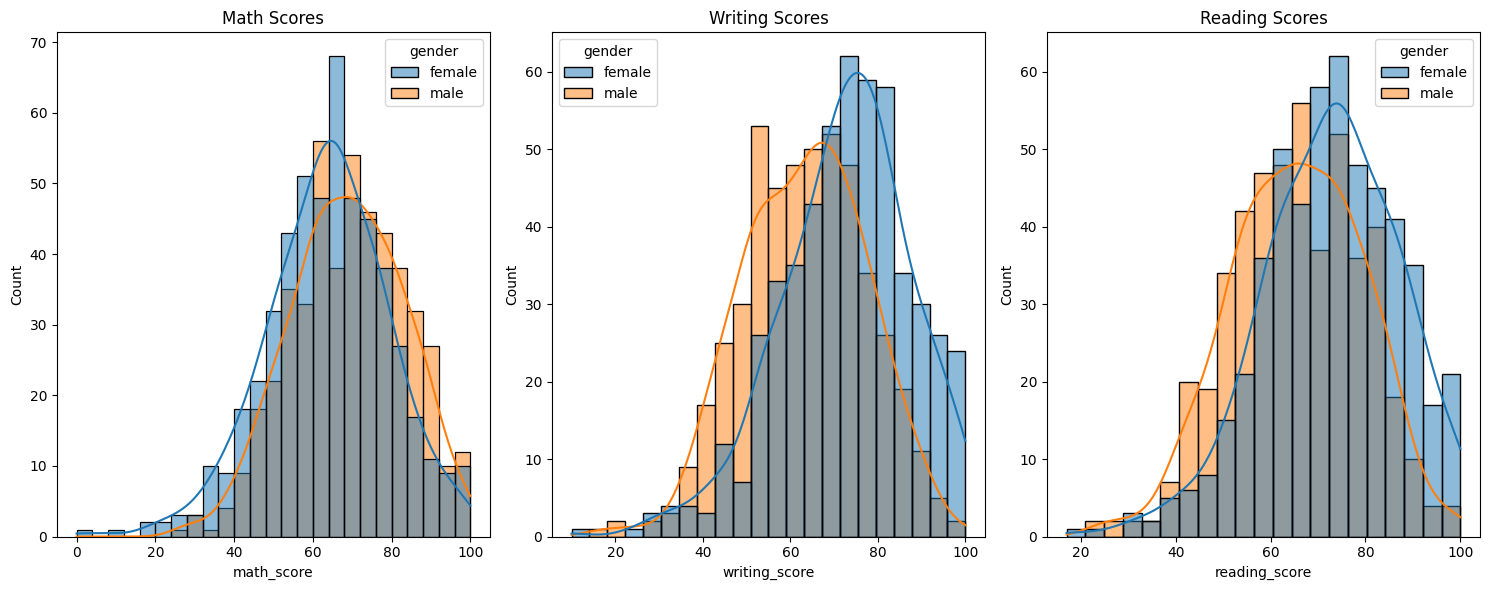

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
col_analize = 'gender'
sns.histplot(data=data, x="math_score", kde=True, hue=col_analize, ax=axs[0])
axs[0].set_title("Math Scores")

sns.histplot(data=data, x="writing_score", kde=True, hue=col_analize, ax=axs[1])
axs[1].set_title("Writing Scores")

sns.histplot(data=data, x="reading_score", kde=True, hue=col_analize, ax=axs[2])
axs[2].set_title("Reading Scores")

plt.tight_layout()
plt.show()

In [15]:
from scipy import stats

groups = [data[data[col_analize] == g]['math_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Math score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")
groups = [data[data[col_analize] == g]['reading_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Reading score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")
groups = [data[data[col_analize] == g]['writing_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Writing score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")

Math score F-statistic(gender): 28.979, p-value: 0.00000
Reading score F-statistic(gender): 63.351, p-value: 0.00000
Writing score F-statistic(gender): 99.592, p-value: 0.00000


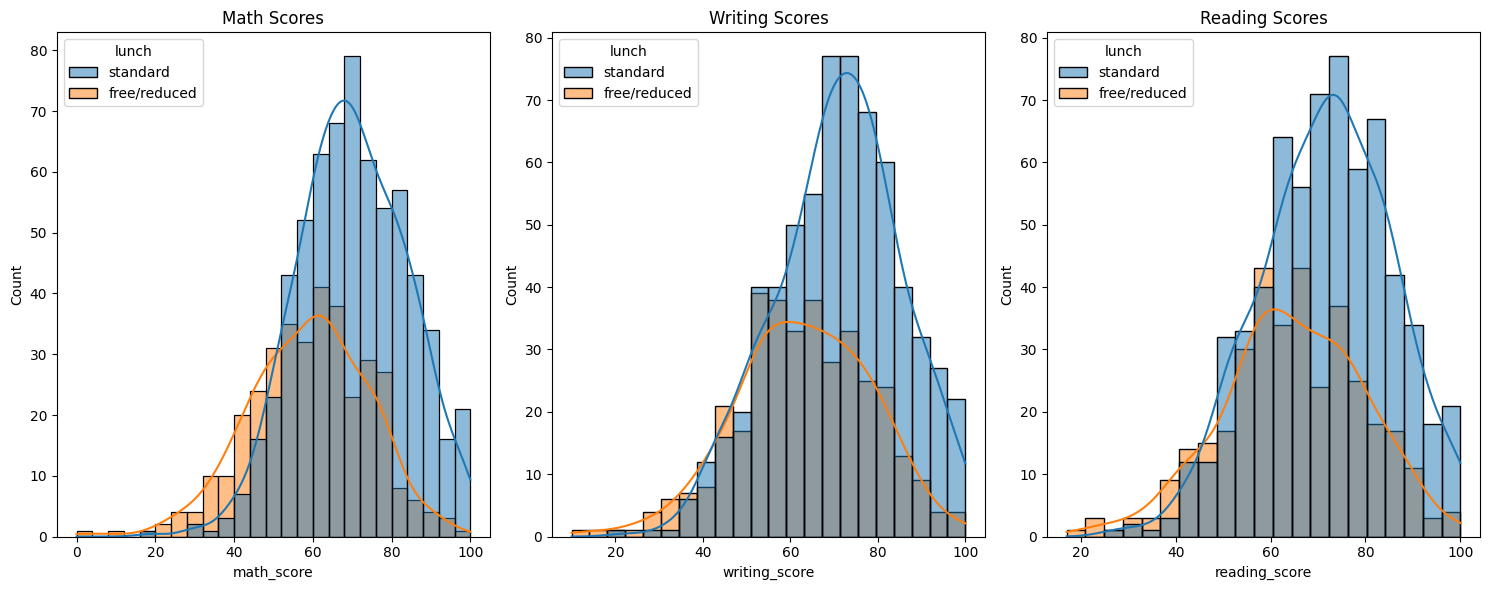

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
col_analize = 'lunch'
sns.histplot(data=data, x="math_score", kde=True, hue=col_analize, ax=axs[0])
axs[0].set_title("Math Scores")

sns.histplot(data=data, x="writing_score", kde=True, hue=col_analize, ax=axs[1])
axs[1].set_title("Writing Scores")

sns.histplot(data=data, x="reading_score", kde=True, hue=col_analize, ax=axs[2])
axs[2].set_title("Reading Scores")

plt.tight_layout()
plt.show()

In [17]:
from scipy import stats

groups = [data[data[col_analize] == g]['math_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Math score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")
groups = [data[data[col_analize] == g]['reading_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Reading score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")
groups = [data[data[col_analize] == g]['writing_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Writing score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")

Math score F-statistic(lunch): 140.119, p-value: 0.00000
Reading score F-statistic(lunch): 55.518, p-value: 0.00000
Writing score F-statistic(lunch): 64.157, p-value: 0.00000


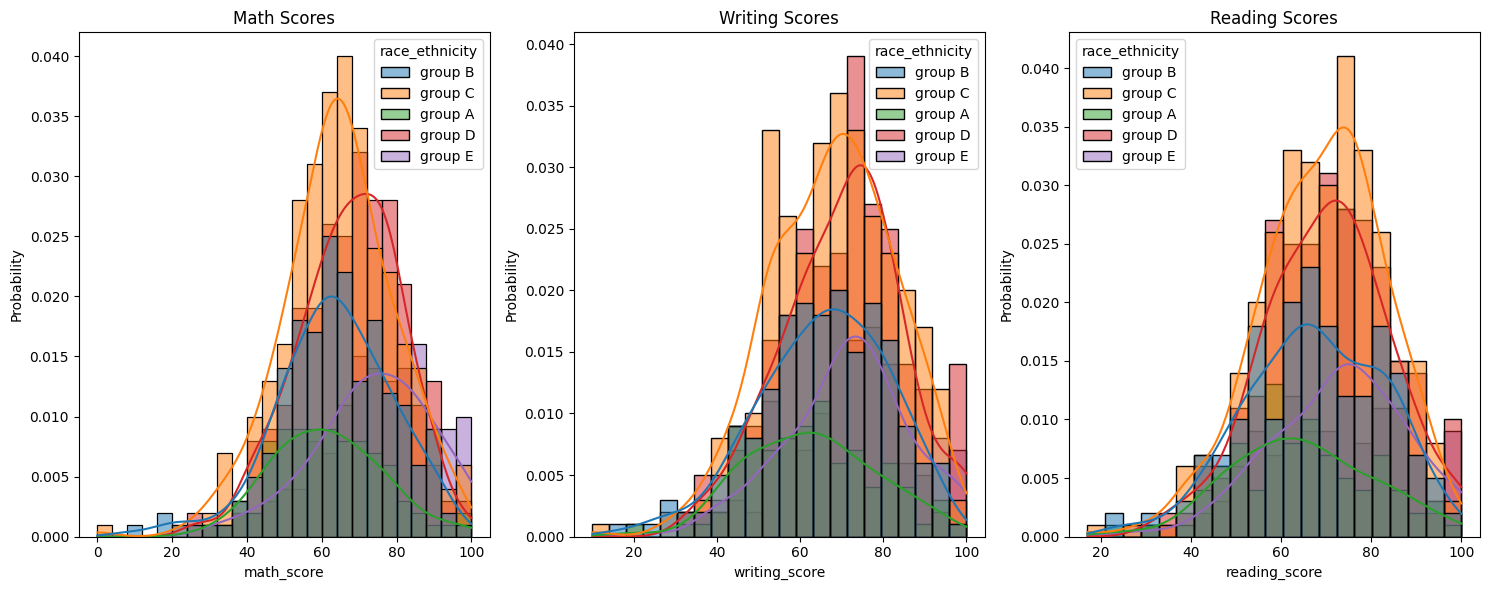

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
col_analize = 'race_ethnicity'
sns.histplot(data=data, x="math_score", kde=True, hue=col_analize, ax=axs[0], stat="probability")
axs[0].set_title("Math Scores")

sns.histplot(data=data, x="writing_score", kde=True, hue=col_analize, ax=axs[1], stat="probability")
axs[1].set_title("Writing Scores")

sns.histplot(data=data, x="reading_score", kde=True, hue=col_analize, ax=axs[2], stat="probability")
axs[2].set_title("Reading Scores")

plt.tight_layout()
plt.show()

In [19]:
from scipy import stats

groups = [data[data[col_analize] == g]['math_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Math score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")
groups = [data[data[col_analize] == g]['reading_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Reading score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")
groups = [data[data[col_analize] == g]['writing_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Writing score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")

Math score F-statistic(race_ethnicity): 14.594, p-value: 0.00000
Reading score F-statistic(race_ethnicity): 5.622, p-value: 0.00018
Writing score F-statistic(race_ethnicity): 7.162, p-value: 0.00001


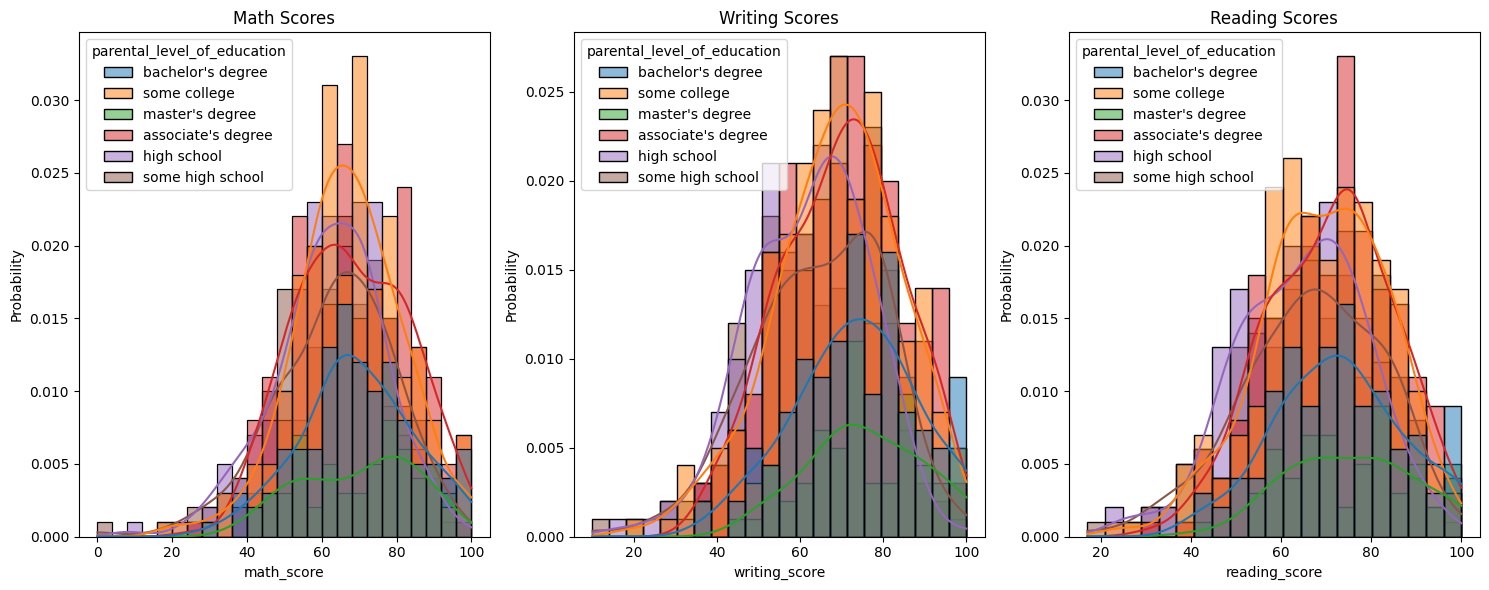

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
col_analize = 'parental_level_of_education'
sns.histplot(data=data, x="math_score", kde=True, hue=col_analize, ax=axs[0], stat="probability")
axs[0].set_title("Math Scores")

sns.histplot(data=data, x="writing_score", kde=True, hue=col_analize, ax=axs[1], stat="probability")
axs[1].set_title("Writing Scores")

sns.histplot(data=data, x="reading_score", kde=True, hue=col_analize, ax=axs[2], stat="probability")
axs[2].set_title("Reading Scores")

plt.tight_layout()
plt.show()

In [21]:
from scipy import stats

groups = [data[data[col_analize] == g]['math_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Math score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")
groups = [data[data[col_analize] == g]['reading_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Reading score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")
groups = [data[data[col_analize] == g]['writing_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Writing score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")

Math score F-statistic(parental_level_of_education): 6.522, p-value: 0.00001
Reading score F-statistic(parental_level_of_education): 9.289, p-value: 0.00000
Writing score F-statistic(parental_level_of_education): 14.442, p-value: 0.00000


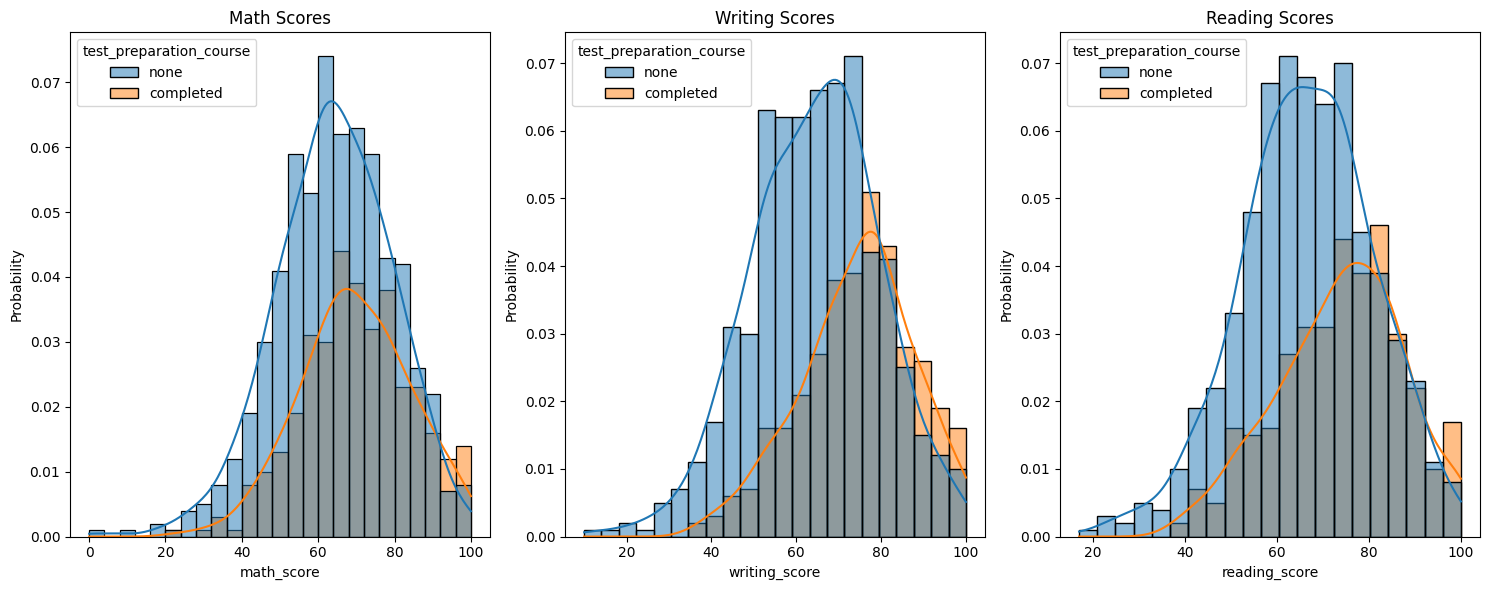

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
col_analize = 'test_preparation_course'
sns.histplot(data=data, x="math_score", kde=True, hue=col_analize, ax=axs[0], stat="probability")
axs[0].set_title("Math Scores")

sns.histplot(data=data, x="writing_score", kde=True, hue=col_analize, ax=axs[1], stat="probability")
axs[1].set_title("Writing Scores")

sns.histplot(data=data, x="reading_score", kde=True, hue=col_analize, ax=axs[2], stat="probability")
axs[2].set_title("Reading Scores")

plt.tight_layout()
plt.show()

In [23]:
from scipy import stats

groups = [data[data[col_analize] == g]['math_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Math score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")
groups = [data[data[col_analize] == g]['reading_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Reading score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")
groups = [data[data[col_analize] == g]['writing_score'] for g in data[col_analize].unique()]
f_stat, p_value = stats.f_oneway(*groups)
print(f"Writing score F-statistic({col_analize}): {f_stat:.3f}, p-value: {p_value:.5f}")

Math score F-statistic(test_preparation_course): 32.543, p-value: 0.00000
Reading score F-statistic(test_preparation_course): 61.963, p-value: 0.00000
Writing score F-statistic(test_preparation_course): 108.351, p-value: 0.00000


In [26]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

cat_cols = ['gender', 'lunch', 'race_ethnicity', 'parental_level_of_education', 'test_preparation_course']
for i, col1 in enumerate(cat_cols):
    for col2 in cat_cols[i+1:]:
        print(f"{col1} vs {col2}: Cramér's V = {cramers_v(data[col1], data[col2]):.3f}")

gender vs lunch: Cramér's V = 0.019
gender vs race_ethnicity: Cramér's V = 0.095
gender vs parental_level_of_education: Cramér's V = 0.058
gender vs test_preparation_course: Cramér's V = 0.004
lunch vs race_ethnicity: Cramér's V = 0.059
lunch vs parental_level_of_education: Cramér's V = 0.033
lunch vs test_preparation_course: Cramér's V = 0.015
race_ethnicity vs parental_level_of_education: Cramér's V = 0.086
race_ethnicity vs test_preparation_course: Cramér's V = 0.074
parental_level_of_education vs test_preparation_course: Cramér's V = 0.098


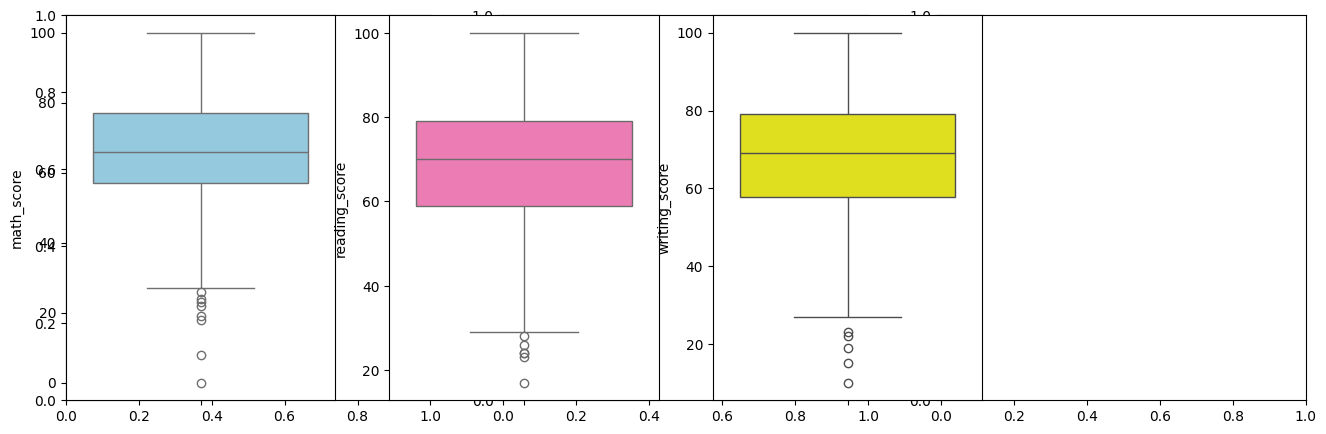

In [ ]:
plt.subplots(1,3,figsize=(16,5))
plt.subplot(141)
sns.boxplot(data['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(data['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(data['writing_score'],color='yellow')
plt.show()

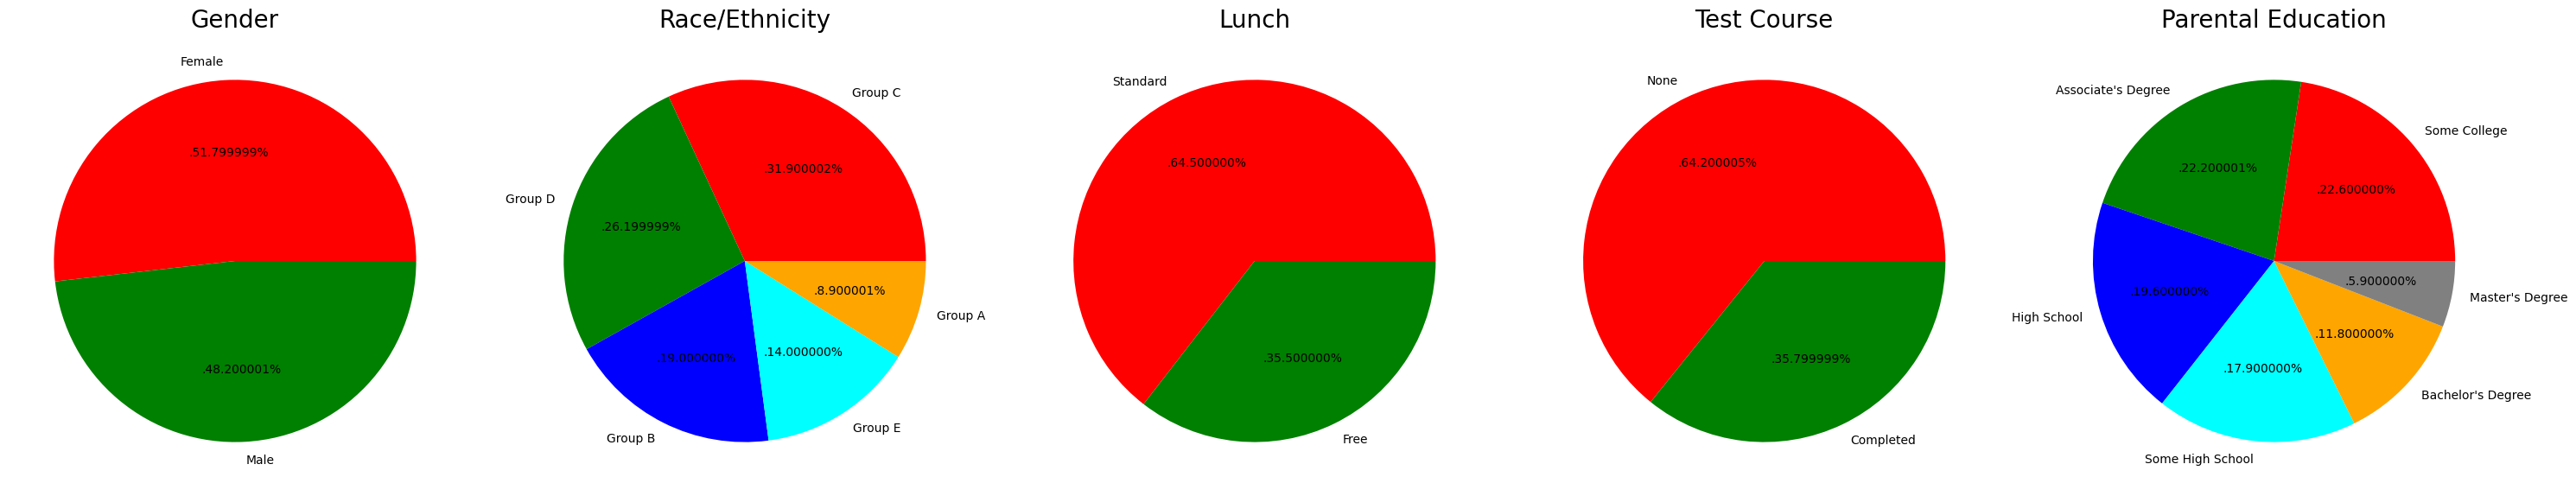

In [ ]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = data['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = data['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = data['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = data['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = data['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

C:\Users\QSUS\AppData\Local\Temp\ipykernel_2960\3230606194.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data['gender'],data=data,palette ='bright',ax=ax[0],saturation=0.95)


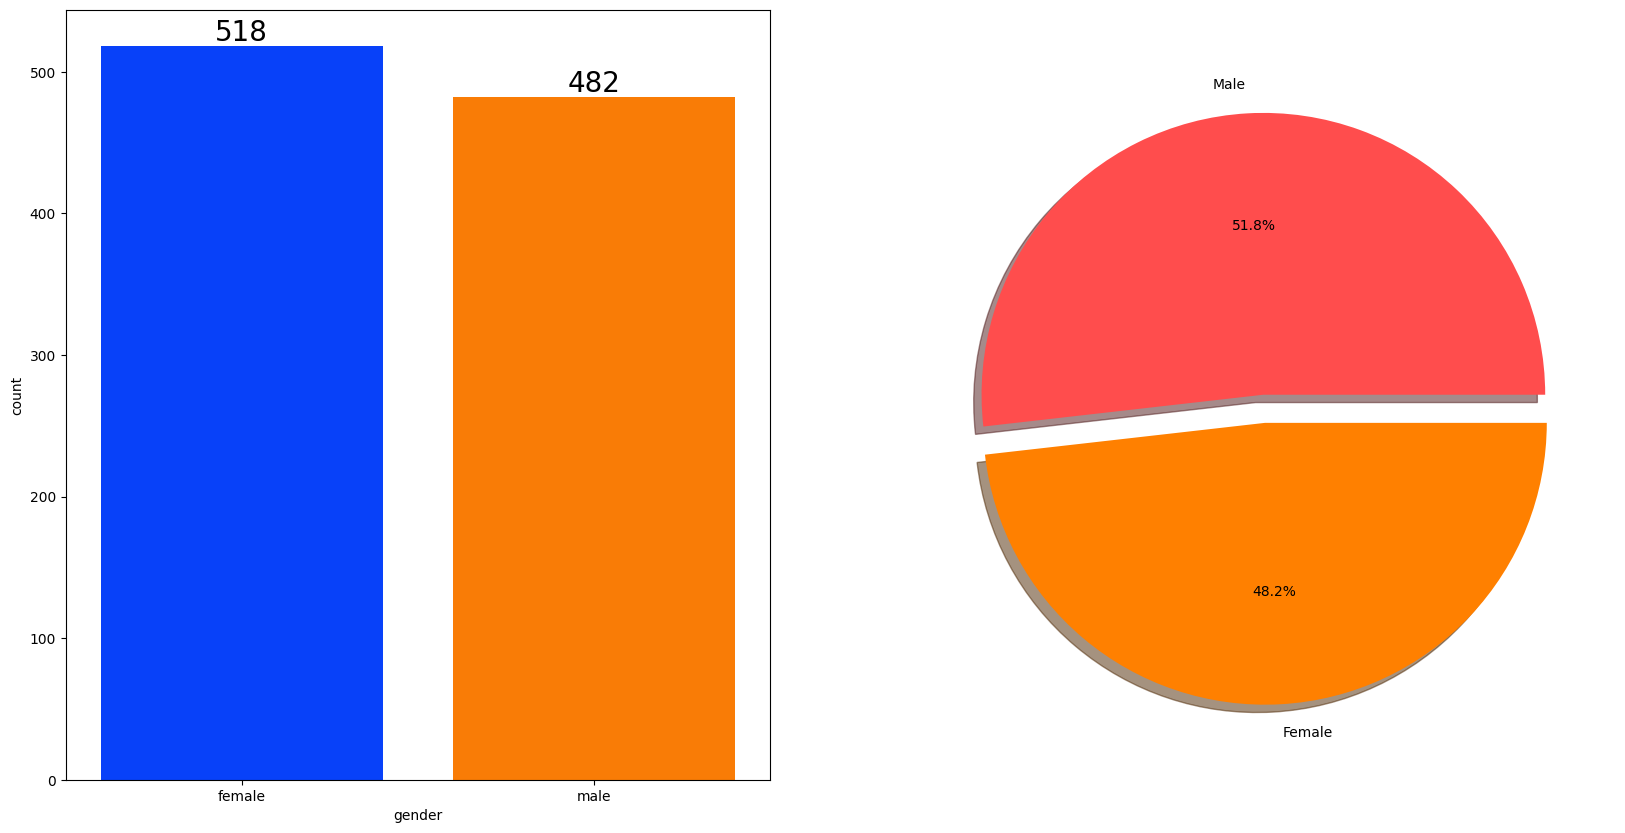

In [ ]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=data['gender'],data=data,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=data['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

C:\Users\QSUS\AppData\Local\Temp\ipykernel_2960\1556097837.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data['race_ethnicity'],data=data,palette = 'bright',ax=ax[0],saturation=0.95)


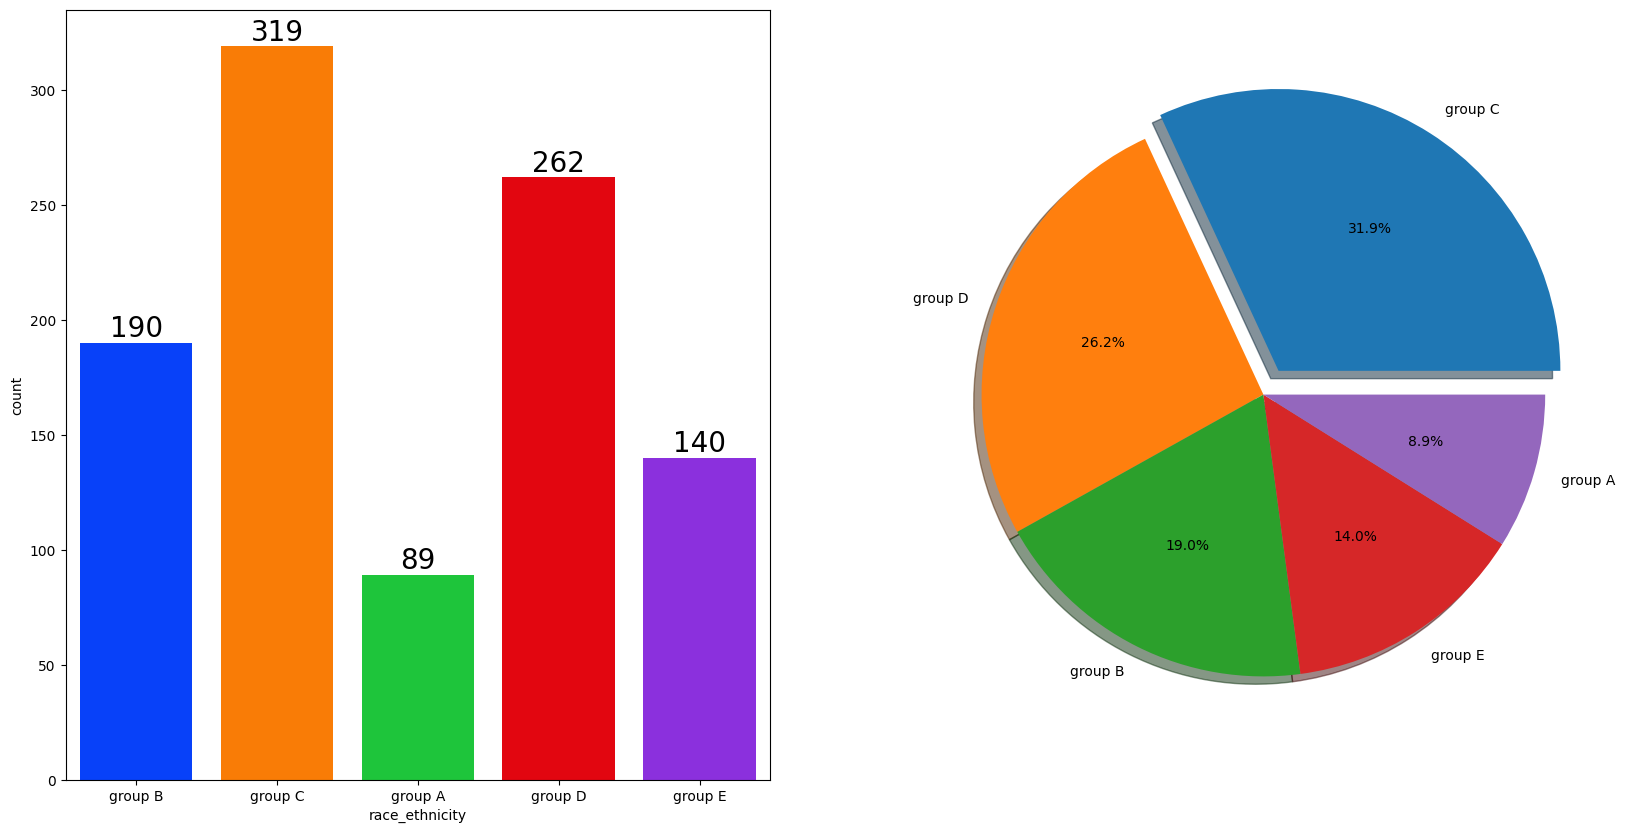

In [ ]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=data['race_ethnicity'],data=data,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = data['race_ethnicity'].value_counts(),labels=data['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()  

C:\Users\QSUS\AppData\Local\Temp\ipykernel_2960\1093158149.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
C:\Users\QSUS\AppData\Local\Temp\ipykernel_2960\1093158149.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
C:\Users\QSUS\AppData\Local\Temp\ipykernel_2960\1093158149.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



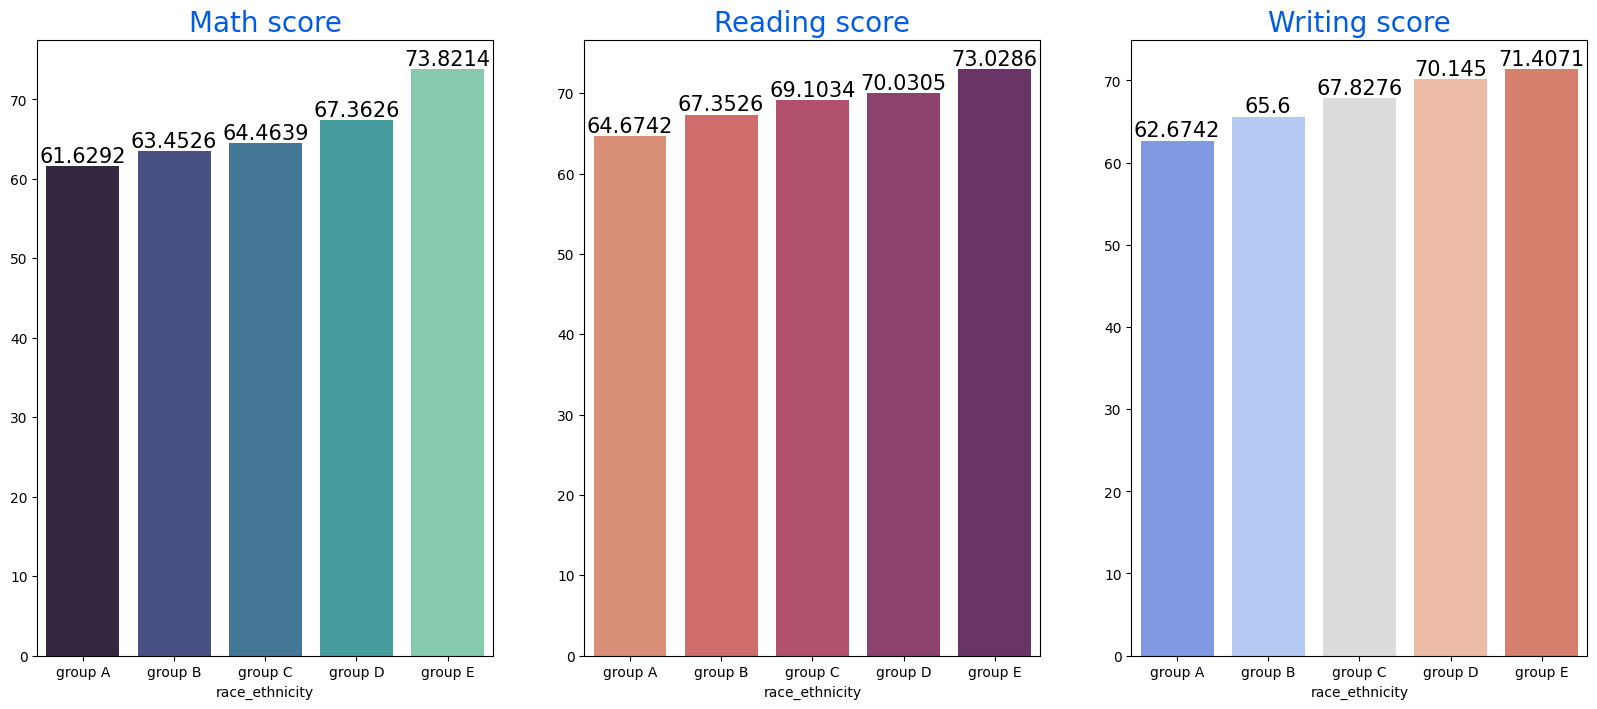

In [ ]:
Group_data2=data.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

C:\Users\QSUS\AppData\Local\Temp\ipykernel_2960\1494885386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data['parental_level_of_education'], palette = 'Blues')


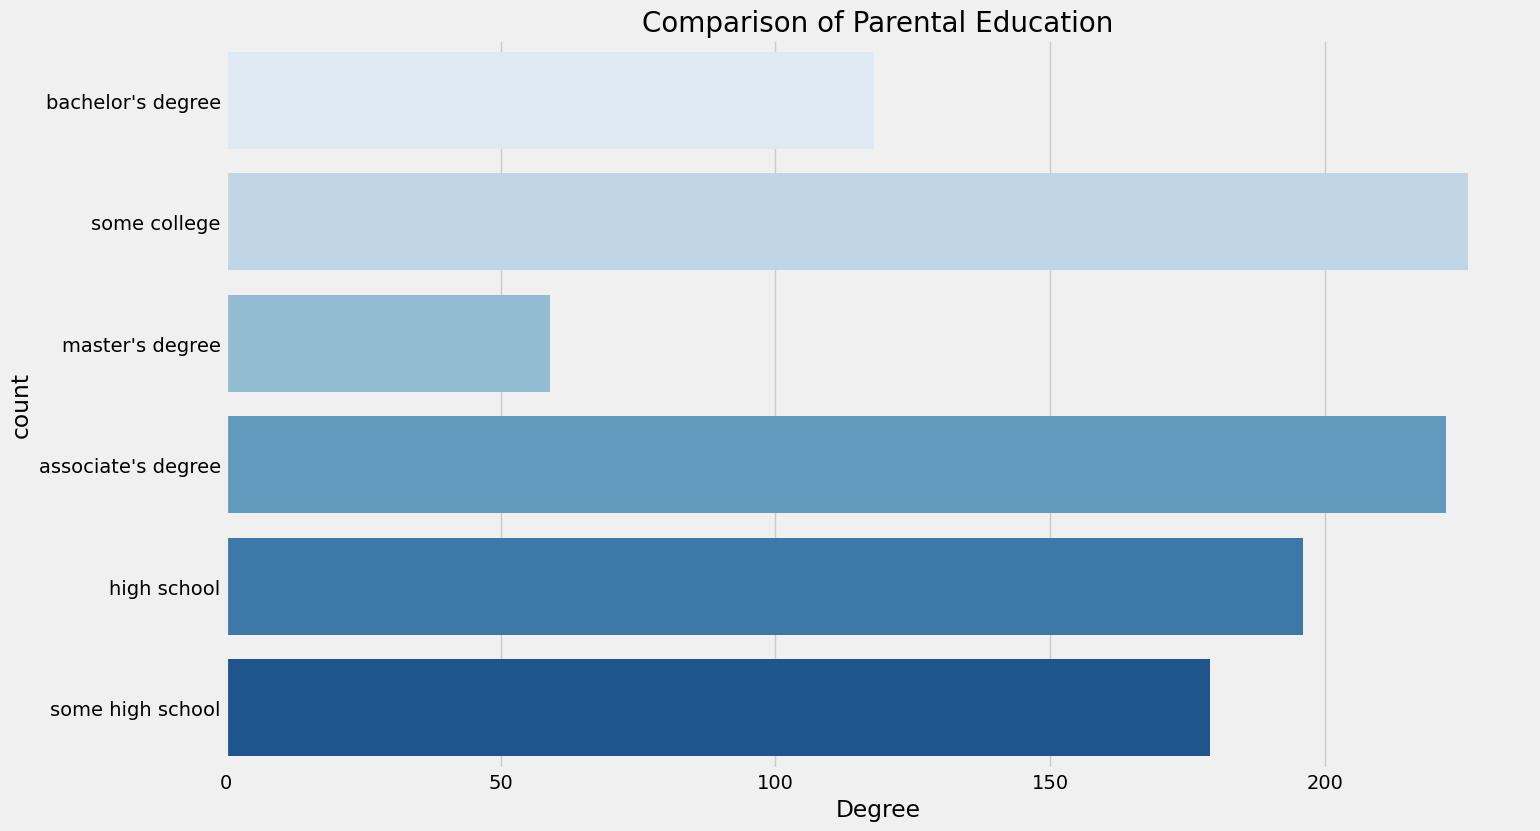

In [ ]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(data['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

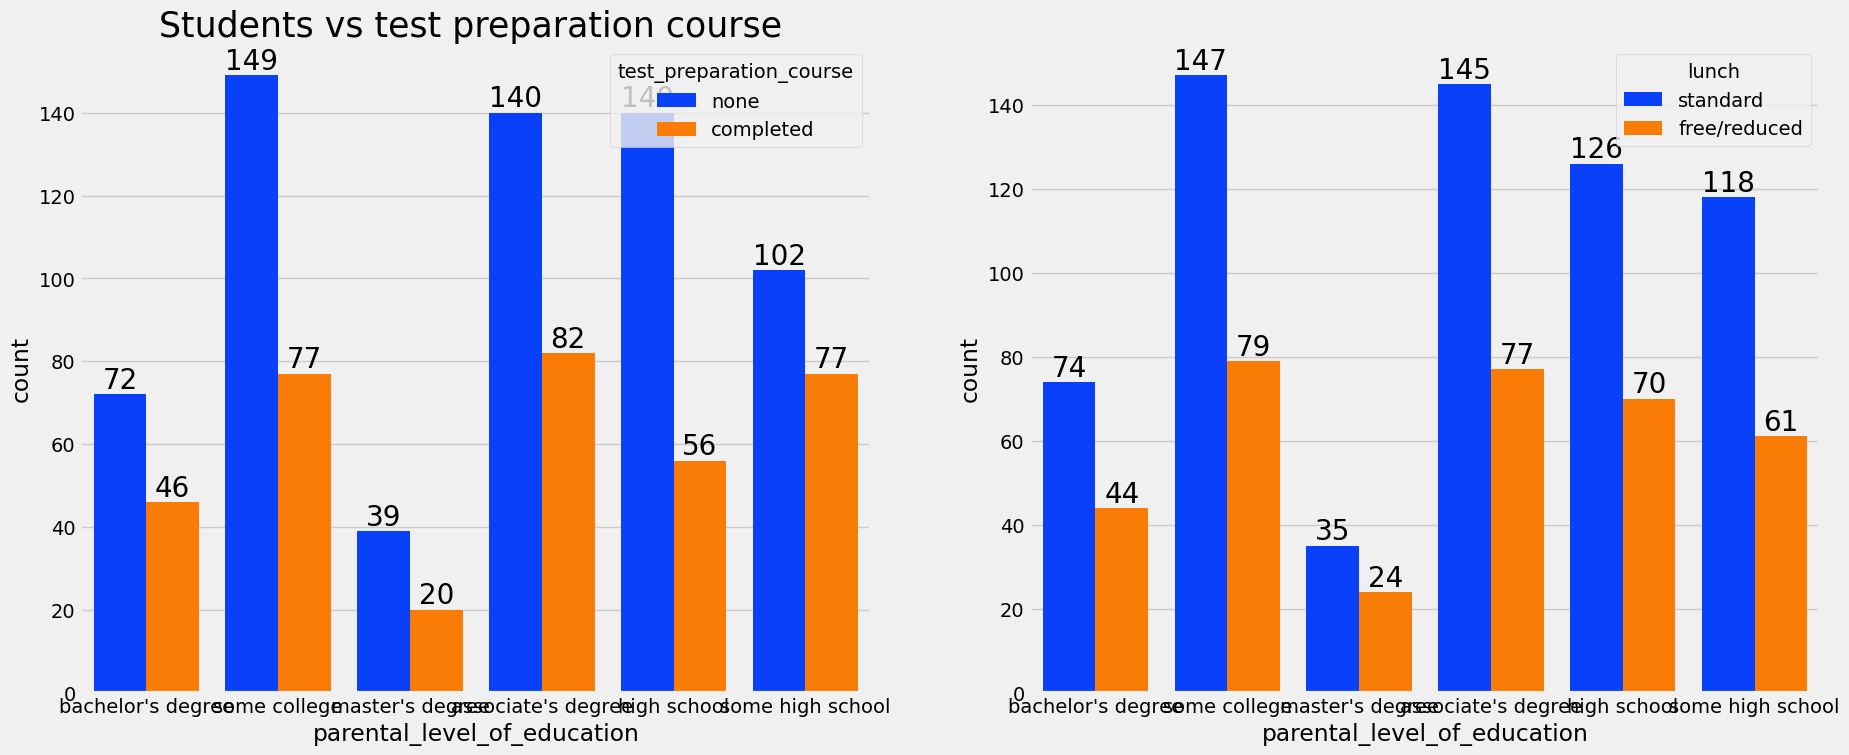

In [ ]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(x=data['parental_level_of_education'],data=data,palette = 'bright',hue='test_preparation_course',saturation=0.95,ax=ax[0])
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
sns.countplot(x=data['parental_level_of_education'],data=data,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)   

<Axes: xlabel='lunch', ylabel='writing_score'>

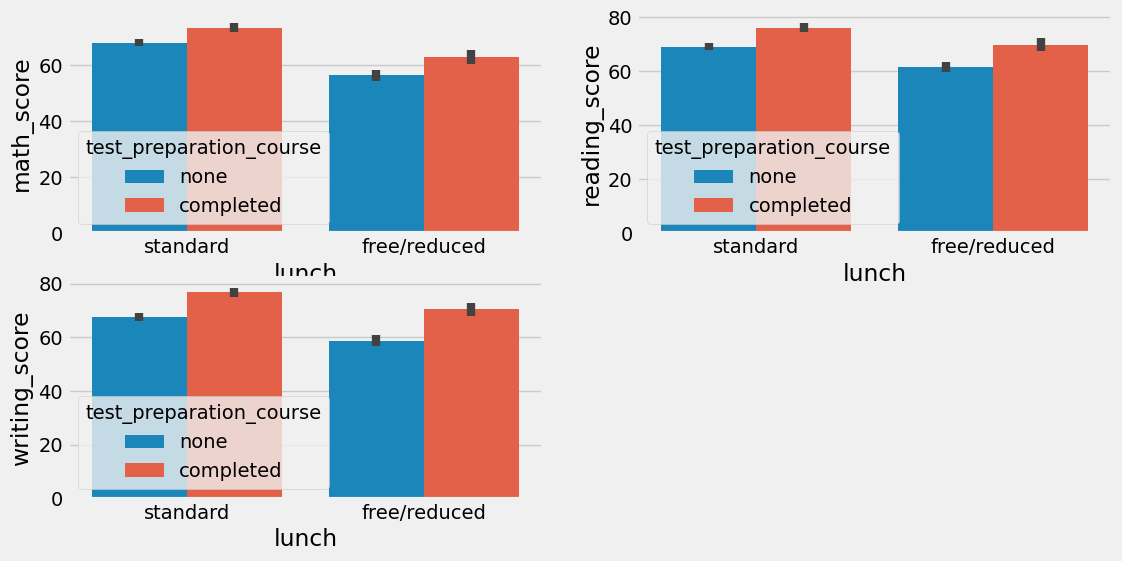

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=data['lunch'], y=data['math_score'], hue=data['test_preparation_course'])
plt.subplot(2,2,2)
sns.barplot (x=data['lunch'], y=data['reading_score'], hue=data['test_preparation_course'])
plt.subplot(2,2,3)
sns.barplot (x=data['lunch'], y=data['writing_score'], hue=data['test_preparation_course'])